# 02 - Input pipeline

How images and labels are fed to the models (`src/data_pipeline.py`), and a few checks that the batches are what the models expect.

- `tf.data` reads the JPEG files listed in `data/splits/<split>.csv`, decodes them and makes batches of `float32` images of shape `(B, 224, 224, 3)` with values in [0, 255].
- Labels: Model 1 gets one label out of 16 classes (`combined_label = fruit * 2 + freshness`), Models 2 and 3 get two labels, `fruit` (0-7) and `freshness` (0 = fresh, 1 = spoiled).
- Only the training split is shuffled and augmented.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from src.config import COMBINED_NAMES, FIGURES_DIR, FRUITS, MODELS_DIR, PROJECT_ROOT
from src.data_pipeline import build_augmenter, labels_for, load_image, load_split, make_dataset
%matplotlib inline

## 1. A training batch with its labels

images: (16, 224, 224, 3) <dtype: 'float32'> range 0.0 - 255.0
fruit labels: (16,) <dtype: 'int32'> | freshness labels: (16,) <dtype: 'float32'>


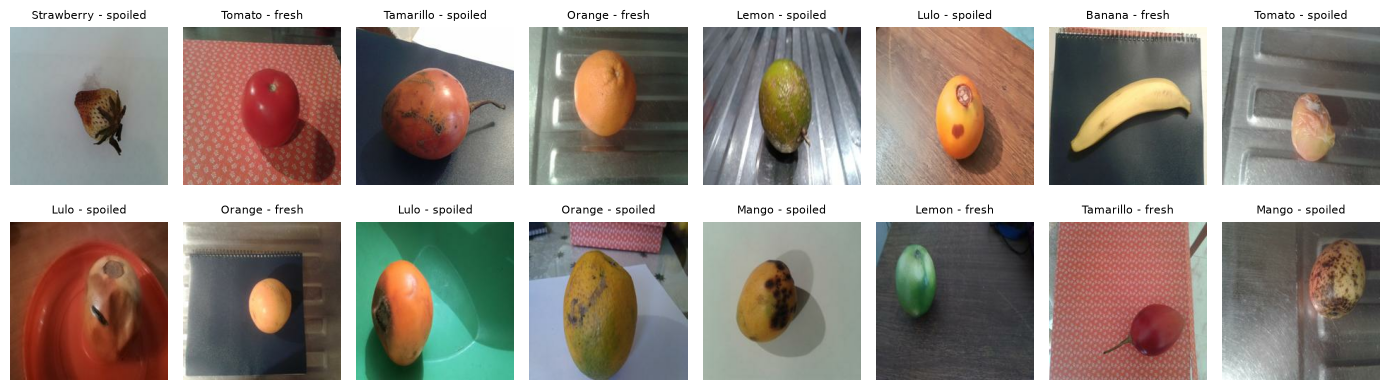

In [2]:
ds = make_dataset("train", label_mode="multitask", batch_size=16, augment=False)
x, y = next(iter(ds))
print("images:", x.shape, x.dtype, "range", float(x.numpy().min()), "-", float(x.numpy().max()))
print("fruit labels:", y["fruit"].shape, y["fruit"].dtype, "| freshness labels:", y["freshness"].shape, y["freshness"].dtype)

fig, axes = plt.subplots(2, 8, figsize=(14, 4.2))
for ax, img, f, s in zip(axes.ravel(), x.numpy(), y["fruit"].numpy(), y["freshness"].numpy()):
    ax.imshow(img.astype("uint8"))
    ax.axis("off")
    ax.set_title(f"{FRUITS[f]} - {'spoiled' if s else 'fresh'}", fontsize=8)
plt.tight_layout()
plt.show()

The titles come from the label tensors and match the pictures. Model 1 uses the combined label of the same rows:

In [3]:
xc, yc = next(iter(make_dataset("val", label_mode="combined", batch_size=16, limit=1)))
print([COMBINED_NAMES[int(c)] for c in yc.numpy()])

['Banana_fresh', 'Lemon_fresh', 'Lulo_fresh', 'Mango_fresh', 'Orange_fresh', 'Strawberry_fresh', 'Tamarillo_fresh', 'Tomato_fresh', 'Banana_spoiled', 'Lemon_spoiled', 'Lulo_spoiled', 'Mango_spoiled', 'Orange_spoiled', 'Strawberry_spoiled', 'Tamarillo_spoiled', 'Tomato_spoiled']


## 2. Data augmentation (training split only)

One image sent through the augmentation layers eight times: random flips, rotation up to 36 degrees (0.1 of a full turn), zoom up to 15 %, brightness and contrast changes up to 15 %. The hue is not changed, because brown and dark spots are what makes a fruit look spoiled.

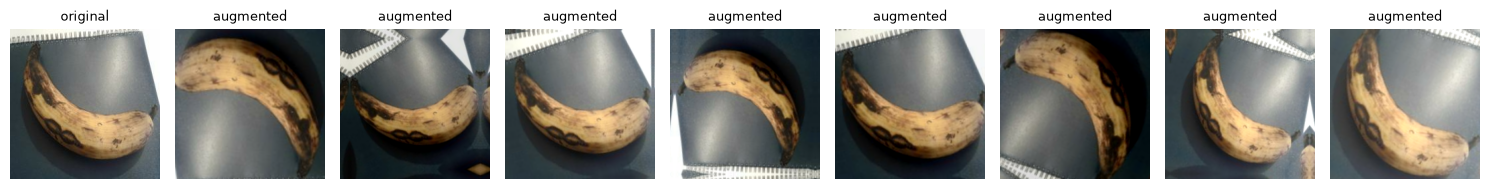

In [4]:
# augmentation: biến đổi ngẫu nhiên ảnh train ở mỗi epoch (lật, xoay, zoom, độ sáng, độ tương phản) để giảm overfitting
augmenter = build_augmenter()
sample = load_split("train").query("combined_name == 'Banana_spoiled'").iloc[0]
img = load_image(PROJECT_ROOT / sample.path)[None]

fig, axes = plt.subplots(1, 9, figsize=(15, 2.3))
axes[0].imshow(img[0].astype("uint8"))
axes[0].set_title("original", fontsize=9)
for ax in axes[1:]:
    ax.imshow(np.clip(augmenter(img, training=True)[0].numpy(), 0, 255).astype("uint8"))
    ax.set_title("augmented", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "augmentation_examples.png", dpi=150, bbox_inches="tight")

## 3. Validation and test batches

No augmentation and no shuffling, so two reads give the same batch and the predictions come out in the order of the CSV file (needed to compare them with the labels later).

In [5]:
first = next(iter(make_dataset("val", batch_size=8, limit=1)))[0].numpy()
again = next(iter(make_dataset("val", batch_size=8, limit=1)))[0].numpy()
print("same validation batch on two reads:", np.array_equal(first, again))

labels = np.concatenate([y.numpy() for _, y in make_dataset("test", label_mode="combined", batch_size=256)])
print("test labels in CSV order:", np.array_equal(labels, labels_for(load_split("test"), "combined")))

same validation batch on two reads: True


test labels in CSV order: True


## 4. Normalisation happens inside the models

The pipeline gives raw pixels and the first layer of each model rescales them: to [0, 1] for Models 1 and 2, and to [-1, 1] for MobileNetV2, which is what its ImageNet weights were trained with. A saved model can therefore be used directly on any RGB image.

In [6]:
# chuẩn hoá nằm ngay trong model: về [0, 1] cho Model 1, 2 và về [-1, 1] cho MobileNetV2
for run in ["model1_simple_cnn", "model2_multitask_cnn", "model3_mobilenet_v2"]:
    model = keras.models.load_model(MODELS_DIR / f"{run}.keras")
    first = next(layer for layer in model.layers if layer.__class__.__name__ == "Rescaling")
    print(f"{model.name:22s} {first.name:26s} scale={first.scale:.6f} offset={first.offset}")

model1_simple_cnn      rescale                    scale=0.003922 offset=0.0


model2_multitask_cnn   rescale                    scale=0.003922 offset=0.0


model3_mobilenet_v2    mobilenet_v2_preprocess    scale=0.007843 offset=-1.0
